In [24]:
library(vegan)      # For RDA and ordination
library(ggplot2)    # For plotting
library(ggrepel)    # For non-overlapping labels in plots
library(tidyverse)  # For data manipulation (dplyr, etc.)
library(e1071)      # Skewness calc

In [27]:
df <- read.csv("C:/Users/leila/Dropbox/MayoWetlands/wetland_alldata_2025_uscore_reduced.csv") #nolint 
# Remove Upland class
df <- df[df$Class != "UL", ]

# remove Hornpeak sites because we are using WTP data now
hornpeak <- c("HPA", "HPB", "HPC", "HPD", "HPE")
df <- df[!df$SiteID %in% hornpeak, ]

names(df)

[1] "SiteID"                "Class"                 "class_num"            
  [4] "Date.Sampled"          "Time.Sampled"          "NDVI_amp_harmonic"    
  [7] "NDVI_phase_harmonic"   "TCW_p10"               "TCW_p40"              
 [10] "TCW_p80"               "TCW_p90"               "SWI_median"           
 [13] "SWI_stdev"             "SWI_p90"               "log_DDG_mean"         
 [16] "log_DDG_median"        "log_DDS_min"           "log_DDS_max"          
 [19] "log_DDS_stdev"         "log_MCA_stdev"         "log_MCA_p90"          
 [22] "log_VDCN_median"       "log_VDCN_mean"         "log_VDCN_min"         
 [25] "log_VDCN_max"          "log_VDCN_stdev"        "HOFD_median"          
 [28] "HOFD_mean"             "HOFD_min"              "HOFD_max"             
 [31] "HOFD_stdev"            "HOFD_p90"              "VOFD_mean"            
 [34] "VOFD_min"              "VOFD_max"              "VOFD_stdev"           
 [37] "VOFD_p90"              "Geom_mode_9"           "Geom_mode_10"         
 [40] "NDVI_MAX"              "NDVI_RANGE"            "NDVI_MEAN"            
 [43] "NDVI_STD"              "NDVI_MEDIAN"           "NDVI_PCT90"           
 [46] "GNDVI_MIN"             "GNDVI_MAX"             "GNDVI_RANGE"          
 [49] "GNDVI_MEAN"            "GNDVI_STD"             "GNDVI_MEDIAN"         
 [52] "GNDVI_PCT90"           "SR_MIN"                "SR_MAX"               
 [55] "SR_RANGE"              "SR_MEAN"               "SR_STD"               
 [58] "SR_MEDIAN"             "SR_PCT90"              "RED_median"           
 [61] "RED_min"               "RED_p25"               "RED_p75"              
 [64] "RED_p95"               "GREEN_max"             "GREEN_min"            
 [67] "GREEN_p25"             "GREEN_IQR"             "REDEDGE_median"       
 [70] "REDEDGE_max"           "REDEDGE_min"           "REDEDGE_p25"          
 [73] "REDEDGE_p95"           "REDEDGE_IQR"           "REDEDGE_stdev"        
 [76] "NIR_mean"              "NIR_median"            "NIR_max"              
 [79] "NIR_min"               "NIR_p25"               "NIR_75"               
 [82] "NIR_iqr"               "average_veg_height"    "median_veg_height"    
 [85] "max_veg_height"        "min_veg_height"        "stddev_veg_height"    
 [88] "P95_veg_height"        "P75_veg_height"        "P25_veg_height"       
 [91] "IQR_veg_height"        "CanopyCover1m"         "CanopyCover2m"        
 [94] "stem_density"          "WTP_max"               "WTP_min"              
 [97] "WTP_median"            "WTP_stdev"             "WTP_range"            
[100] "Recharge"              "Discharge"             "unknown_hydro"        
[103] "VHG_average"           "VHG_median"            "VHG_max"              
[106] "VHG_min"               "VHG_stdev"             "VHG_range"            
[109] "small_tree"            "shrub"                 "graminoid"            
[112] "moss"                  "lichen"                "dom_tall_tree_none"   
[115] "dom_small_tree_will"   "dom_small_tree_spruce" "dom_small_tree_none"  
[118] "dom_graminoid_grass"   "equisetum_dom"         "Al"                   
[121] "As"                    "Ba"                    "Cd"                   
[124] "Ca"                    "Co"                    "Cu"                   
[127] "F"                     "Fe"                    "Mg"                   
[130] "Mn"                    "Mo"                    "K"                    
[133] "Rb"                    "Se"                    "Si"                   
[136] "Na"                    "S"                     "Ti"                   
[139] "U"                     "DOC"                   "TOC"                  
[142] "P_total"               "NH3_total"             "Hardness"             
[145] "SO4_mg.L"              "Dissolved_O_percent"   "Dissolved_O_mgL"      
[148] "pH"                    "ORPmV"

In [26]:
# ============================================================================
# STEP 2: Define variable groups (column ranges)
# ============================================================================

# Vegetation UAV ALL (predictor RDA1)
#veg_start <- which(names(df) == "REDEDGE_min")  
#veg_end   <- which(names(df) == "stem_density")      
#veg_cols <- names(df)[veg_start:veg_end]

# Veg - UAV structure only
struct_start <- which(names(df)=="average_veg_height")
struct_end   <- which(names(df) == "stem_density")
struct_cols  <- names(df)[struct_start:struct_end]

# Veg - UAV MS only
ms_start <- which(names(df)=="NDVI_MAX")
ms_end   <- which(names(df) == "NIR_iqr")
ms_cols <- names(df)[ms_start:ms_end]

# Field veg 
field_start <- which(names(df)=="small_tree")
field_end   <- which(names(df)=="equisetum_dom")
field_cols <- names(df)[field_start:field_end]

# Hydrology (predictors for RDA1, response for RDA2)
hydro_start <- which(names(df) == "WTP_max")      # or your first hydro col
hydro_end   <- which(names(df) == "VHG_range")  # adjust as needed
hydro_cols <- names(df)[hydro_start:hydro_end]

# Chemistry (predictors for RDA1, response for RDA2)
chem_start <- which(names(df) == "Al")
chem_end   <- which(names(df) == "ORPmV")
chem_cols <- names(df)[chem_start:chem_end]

# Topography (predictors for RDA2)
#topo_start <- which(names(df) == "SWI_median")
#topo_end   <- which(names(df) == "Geom_mode_10")
#topo_cols <- names(df)[topo_start:topo_end]

# stat remotes
sat_start <- which(names(df) == "NDVI_amp_harmonic")
sat_end <- which(names(df) == "TCW_p90")

# UAV structure & indices (for reference/additional analysis if needed)
#uav_veg_cols <- c("median_veg_height", "average_veg_height", "NDVI_MEAN", "NDGVI_MEAN")  # adjust

In [9]:
print(ms_cols)

 [1] "NDVI_MAX"       "NDVI_RANGE"     "NDVI_MEAN"      "NDVI_STD"      
 [5] "NDVI_MEDIAN"    "NDVI_PCT90"     "GNDVI_MIN"      "GNDVI_MAX"     
 [9] "GNDVI_RANGE"    "GNDVI_MEAN"     "GNDVI_STD"      "GNDVI_MEDIAN"  
[13] "GNDVI_PCT90"    "SR_MIN"         "SR_MAX"         "SR_RANGE"      
[17] "SR_MEAN"        "SR_STD"         "SR_MEDIAN"      "SR_PCT90"      
[21] "RED_median"     "RED_min"        "RED_p25"        "RED_p75"       
[25] "RED_p95"        "GREEN_max"      "GREEN_min"      "GREEN_p25"     
[29] "GREEN_IQR"      "REDEDGE_median" "REDEDGE_max"    "REDEDGE_min"   
[33] "REDEDGE_p25"    "REDEDGE_p95"    "REDEDGE_IQR"    "REDEDGE_stdev" 
[37] "NIR_mean"       "NIR_median"     "NIR_max"        "NIR_min"       
[41] "NIR_p25"        "NIR_75"         "NIR_iqr"       


In [10]:
print(hydro_cols)

 [1] "WTP_max"       "WTP_min"       "WTP_median"    "WTP_stdev"    
 [5] "WTP_range"     "Recharge"      "Discharge"     "unknown_hydro"
 [9] "VHG_average"   "VHG_median"    "VHG_max"       "VHG_min"      
[13] "VHG_stdev"     "VHG_range"    


In [11]:
print(ms_cols)

 [1] "NDVI_MAX"       "NDVI_RANGE"     "NDVI_MEAN"      "NDVI_STD"      
 [5] "NDVI_MEDIAN"    "NDVI_PCT90"     "GNDVI_MIN"      "GNDVI_MAX"     
 [9] "GNDVI_RANGE"    "GNDVI_MEAN"     "GNDVI_STD"      "GNDVI_MEDIAN"  
[13] "GNDVI_PCT90"    "SR_MIN"         "SR_MAX"         "SR_RANGE"      
[17] "SR_MEAN"        "SR_STD"         "SR_MEDIAN"      "SR_PCT90"      
[21] "RED_median"     "RED_min"        "RED_p25"        "RED_p75"       
[25] "RED_p95"        "GREEN_max"      "GREEN_min"      "GREEN_p25"     
[29] "GREEN_IQR"      "REDEDGE_median" "REDEDGE_max"    "REDEDGE_min"   
[33] "REDEDGE_p25"    "REDEDGE_p95"    "REDEDGE_IQR"    "REDEDGE_stdev" 
[37] "NIR_mean"       "NIR_median"     "NIR_max"        "NIR_min"       
[41] "NIR_p25"        "NIR_75"         "NIR_iqr"       


## NEW: Remove redunant information

In [12]:
# ============================================================================
# STEP 2b: Remove redundant predictor information 
# (KEEP medians, DROP means + ranges for MS and structure)
# ============================================================================

# Backup original predictor lists (optional for debugging)
ms_cols_full     <- ms_cols
struct_cols_full <- struct_cols

# ---------------------------------------------------------------------------
# 1) DROP MEAN-type MS / band predictors (keep MEDIAN versions instead)
# ---------------------------------------------------------------------------
mean_like_ms <- ms_cols[grepl("_MEAN|mean", ms_cols, ignore.case = TRUE)]
ms_cols <- setdiff(ms_cols, mean_like_ms)

# ---------------------------------------------------------------------------
# 2) DROP RANGE-type MS / band predictors (e.g., NDVI_RANGE, SR_RANGE)
# ---------------------------------------------------------------------------
range_like_ms <- ms_cols[grepl("_RANGE|range", ms_cols, ignore.case = TRUE)]
ms_cols <- setdiff(ms_cols, range_like_ms)

# ---------------------------------------------------------------------------
# 3) STRUCTURE: Drop average_veg_height (redundant with median)
# ---------------------------------------------------------------------------
redundant_struct <- intersect(struct_cols, c("average_veg_height"))
struct_cols <- setdiff(struct_cols, redundant_struct)

# ---------------------------------------------------------------------------
# 4) OPTIONAL diagnostic prints
# ---------------------------------------------------------------------------
cat("\nDropped MEAN-type MS predictors:\n")
print(mean_like_ms)

cat("\nDropped RANGE-type MS predictors:\n")
print(range_like_ms)

cat("\nDropped redundant structure predictors:\n")
print(redundant_struct)

cat("\n\nFinal MS predictor set:\n")
print(ms_cols)

cat("\nFinal Structure predictor set:\n")
print(struct_cols)



Dropped MEAN-type MS predictors:
[1] "NDVI_MEAN"  "GNDVI_MEAN" "SR_MEAN"    "NIR_mean"  

Dropped RANGE-type MS predictors:
[1] "NDVI_RANGE"  "GNDVI_RANGE" "SR_RANGE"   

Dropped redundant structure predictors:
[1] "average_veg_height"


Final MS predictor set:
 [1] "NDVI_MAX"       "NDVI_STD"       "NDVI_MEDIAN"    "NDVI_PCT90"    
 [5] "GNDVI_MIN"      "GNDVI_MAX"      "GNDVI_STD"      "GNDVI_MEDIAN"  
 [9] "GNDVI_PCT90"    "SR_MIN"         "SR_MAX"         "SR_STD"        
[13] "SR_MEDIAN"      "SR_PCT90"       "RED_median"     "RED_min"       
[17] "RED_p25"        "RED_p75"        "RED_p95"        "GREEN_max"     
[21] "GREEN_min"      "GREEN_p25"      "GREEN_IQR"      "REDEDGE_median"
[25] "REDEDGE_max"    "REDEDGE_min"    "REDEDGE_p25"    "REDEDGE_p95"   
[29] "REDEDGE_IQR"    "REDEDGE_stdev"  "NIR_median"     "NIR_max"       
[33] "NIR_min"        "NIR_p25"        "NIR_75"         "NIR_iqr"       

Final Structure predictor set:
 [1] "median_veg_height" "max_veg_height"    "mi

In [13]:
# ============================================================================
# STEP 4: Prepare Response Data (Chemistry + Hydrology)
# ============================================================================

# Remove VHG and WTP columns from hydro_cols
#hydro_cols <- hydro_cols[!grepl("VHG|WTP", hydro_cols)]

## NEW: Keep WTP, Drop VHG ALD is a proxy for Bog WTP vars
hydro_cols <- hydro_cols[!grepl("VHG", hydro_cols)]

# Get hydrology data
hydro_data <- df[, hydro_cols]
rownames(hydro_data) <- df$SiteID

# Get chemistry data (already u-score transformed in the CSV)
chem_data <- df[, chem_cols]
rownames(chem_data) <- df$SiteID

# Combine chemistry (u-score dataframe) with hydrology data as RESPONSE
response <- cbind(chem_data, hydro_data)
rownames(response) <- df$SiteID

# ============================================================================
# STEP 5: Prepare Predictor Data (Vegetation)
# ============================================================================

predictors <- df[, c(ms_cols, struct_cols)]
rownames(predictors) <- df$SiteID

# NEW: Remove highly cor or no variation vars
apply(predictors, 2, function(x) length(unique(x)))
which(abs(cor(predictors, use="pairwise.complete.obs")) > 0.99999, arr.ind = TRUE)
# 1. Find zero-variance or all-NA predictors
pred_sds <- apply(predictors, 2, sd, na.rm = TRUE)

zero_var_preds <- names(pred_sds[is.na(pred_sds) | pred_sds == 0])
print( zero_var_preds)
# Look at this list – these are variables that are constant or all NA

# 2. Drop them from predictors
predictors <- predictors[, !(names(predictors) %in% zero_var_preds), drop = FALSE]

cm <- cor(predictors, use = "pairwise.complete.obs")
diag(cm) <- NA

perfect_pairs <- which(abs(cm) == 1, arr.ind = TRUE)
perfect_pairs




NDVI_MAX          NDVI_STD       NDVI_MEDIAN        NDVI_PCT90 
               18                20                20                21 
        GNDVI_MIN         GNDVI_MAX         GNDVI_STD      GNDVI_MEDIAN 
               20                20                20                20 
      GNDVI_PCT90            SR_MIN            SR_MAX            SR_STD 
               20                21                21                21 
        SR_MEDIAN          SR_PCT90        RED_median           RED_min 
               21                21                20                20 
          RED_p25           RED_p75           RED_p95         GREEN_max 
               20                20                20                20 
        GREEN_min         GREEN_p25         GREEN_IQR    REDEDGE_median 
               20                20                20                20 
      REDEDGE_max       REDEDGE_min       REDEDGE_p25       REDEDGE_p95 
               20                19                20                20 
      REDEDGE_IQR     REDEDGE_stdev        NIR_median           NIR_max 
               20                20                20                20 
          NIR_min           NIR_p25            NIR_75           NIR_iqr 
               20                20                20                20 
median_veg_height    max_veg_height    min_veg_height stddev_veg_height 
               14                19                 1                19 
   P95_veg_height    P75_veg_height    P25_veg_height    IQR_veg_height 
               19                18                12                17 
    CanopyCover1m     CanopyCover2m      stem_density 
               13                 9                13

Warning message in cor(predictors, use = "pairwise.complete.obs"):
"the standard deviation is zero"


,row,col
NDVI_MAX,1,1
NDVI_STD,2,2
NDVI_MEDIAN,3,3
NDVI_PCT90,4,4
GNDVI_MIN,5,5
GNDVI_MAX,6,6
GNDVI_STD,7,7
GNDVI_MEDIAN,8,8
GNDVI_PCT90,9,9
SR_MIN,10,10


[1] "min_veg_height"


row,col


In [14]:
# ============================================================================
# STEP 6: Fit RDA1
# ============================================================================
rda_global <- rda(response ~ ., data = predictors, scale  = TRUE)
summary(rda_global)


Call:
rda(formula = response ~ NDVI_MAX + NDVI_STD + NDVI_MEDIAN +      NDVI_PCT90 + GNDVI_MIN + GNDVI_MAX + GNDVI_STD + GNDVI_MEDIAN +      GNDVI_PCT90 + SR_MIN + SR_MAX + SR_STD + SR_MEDIAN + SR_PCT90 +      RED_median + RED_min + RED_p25 + RED_p75 + RED_p95 + GREEN_max +      GREEN_min + GREEN_p25 + GREEN_IQR + REDEDGE_median + REDEDGE_max +      REDEDGE_min + REDEDGE_p25 + REDEDGE_p95 + REDEDGE_IQR + REDEDGE_stdev +      NIR_median + NIR_max + NIR_min + NIR_p25 + NIR_75 + NIR_iqr +      median_veg_height + max_veg_height + stddev_veg_height +      P95_veg_height + P75_veg_height + P25_veg_height + IQR_veg_height +      CanopyCover1m + CanopyCover2m + stem_density, data = predictors,      scale = TRUE) 

Partitioning of correlations:
              Inertia Proportion
Total           38.00     1.0000
Constrained     24.53     0.6454
Unconstrained   13.47     0.3546

Eigenvalues, and their contribution to the correlations 

Importance of components:
                        RDA1   RDA2

In [15]:
# --- VIFs (for diagnostics) ---
# vif.cca() returns VIF; you want sqrt(VIF) for your rule (sqrt(VIF) > 2)
vif_global        <- vif.cca(rda_global)
sqrt_vif_global   <- sqrt(vif_global)

cat("\nRaw VIF values (global model):\n")
print(vif_global)

cat("\nSqrt(VIF) values (global model):\n")
print(sqrt_vif_global)

# Sort by sqrt(VIF), descending
sqrt_vif_sorted <- sort(sqrt_vif_global, decreasing = TRUE)
cat("\nSqrt(VIF), sorted (descending):\n")
print(sqrt_vif_sorted)

# Identify variables with high VIF according to your rule: sqrt(VIF) > 2  (=> VIF > 4)
high_vif_global <- sqrt_vif_global[sqrt_vif_global > 2]
cat("\nVariables with sqrt(VIF) > 2 (i.e. VIF > 4):\n")
print(high_vif_global)


Raw VIF values (global model):
         NDVI_MAX          NDVI_STD       NDVI_MEDIAN        NDVI_PCT90 
     3.690927e+05      9.478206e+10      3.612656e+11      6.358393e+10 
        GNDVI_MIN         GNDVI_MAX         GNDVI_STD      GNDVI_MEDIAN 
     5.570542e+09      1.849090e+09      1.484598e+10      3.891930e+11 
      GNDVI_PCT90            SR_MIN            SR_MAX            SR_STD 
     2.425680e+11      2.498474e+08      1.055626e+08      1.685445e+11 
        SR_MEDIAN          SR_PCT90        RED_median           RED_min 
     7.169361e+10      2.431044e+11      2.645831e+10      9.526564e+09 
          RED_p25           RED_p75           RED_p95         GREEN_max 
     5.243610e+10      1.506394e+11      1.766872e+09      9.360243e+10 
        GREEN_min         GREEN_p25         GREEN_IQR    REDEDGE_median 
     1.399634e+09      5.694085e+10                NA                NA 
      REDEDGE_max       REDEDGE_min       REDEDGE_p25       REDEDGE_p95 
               NA  

In [17]:
# ============================================================================
# STEP 7: Model Statistics
# ============================================================================

# Adjusted R-squared
r2_global <- RsquareAdj(rda_global)
print(r2_global)

# Overall model significance
anova_global <- anova.cca(rda_global, permutations = 999)
print(anova_global)

# Test each axis
anova.cca(rda_global, by = "axis", permutations = 999)

# Test each predictor variable
anova.cca(rda_global, by = "term", permutations = 999)

$r.squared
[1] 0.6454187

$adj.r.squared
[1] 0.4401348

Permutation test for rda under reduced model
Permutation: free
Number of permutations: 999

Model: rda(formula = response ~ NDVI_MAX + NDVI_STD + NDVI_MEDIAN + NDVI_PCT90 + GNDVI_MIN + GNDVI_MAX + GNDVI_STD + GNDVI_MEDIAN + GNDVI_PCT90 + SR_MIN + SR_MAX + SR_STD + SR_MEDIAN + SR_PCT90 + RED_median + RED_min + RED_p25 + RED_p75 + RED_p95 + GREEN_max + GREEN_min + GREEN_p25 + GREEN_IQR + REDEDGE_median + REDEDGE_max + REDEDGE_min + REDEDGE_p25 + REDEDGE_p95 + REDEDGE_IQR + REDEDGE_stdev + NIR_median + NIR_max + NIR_min + NIR_p25 + NIR_75 + NIR_iqr + median_veg_height + max_veg_height + stddev_veg_height + 
    P95_veg_height + P75_veg_height + P25_veg_height + IQR_veg_height + CanopyCover1m + CanopyCover2m + stem_density, data = predictors, scale = TRUE)
         Df Variance     F Pr(>F)    
Model    22   24.526 3.144  0.001 ***
Residual 38   13.474                 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,4.29838527,12.1224261,0.001
RDA2,1,4.03439532,11.3779143,0.001
RDA3,1,3.13899237,8.8526739,0.001
RDA4,1,2.25662531,6.3641977,0.001
RDA5,1,2.01378434,5.6793308,0.001
RDA6,1,1.63874566,4.6216362,0.015
RDA7,1,1.45157306,4.0937668,0.034
RDA8,1,1.07233570,3.0242311,0.480
RDA9,1,0.79788899,2.2502288,0.963


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
NDVI_MAX,1,0.7477087,2.1087090,0.007
NDVI_STD,1,1.2485891,3.5213058,0.001
NDVI_MEDIAN,1,0.7111560,2.0056220,0.008
NDVI_PCT90,1,0.9230448,2.6031968,0.001
GNDVI_MIN,1,1.6815715,4.7424149,0.001
GNDVI_MAX,1,1.3084478,3.6901209,0.001
GNDVI_STD,1,1.6153426,4.5556343,0.001
GNDVI_MEDIAN,1,0.9614359,2.7114684,0.002
GNDVI_PCT90,1,1.4673695,4.1383164,0.001


## Plot Global RDA

In [ ]:
# ============================================================================
# STEP 8: Extract Scores for Plotting
# ============================================================================

# Site scores
site_scores <- as.data.frame(scores(rda1, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class <- df$Class  # Add wetland class for coloring

# Predictor arrows (vegetation variables)
arrow_scores <- as.data.frame(scores(rda1, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

# Response arrows (hydrogeochemistry variables)
response_scores <- as.data.frame(scores(rda1, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# Get axis labels with variance explained
eig <- summary(rda1)$concont$importance[2, 1:2]
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

In [ ]:
# ============================================================================
# STEP 9: Scale arrows for visibility
# ============================================================================

# Scale vegetation predictors (red arrows)
arrow_scale_veg <- 6
arrow_scores$RDA1_scaled <- arrow_scores$RDA1 * arrow_scale_veg
arrow_scores$RDA2_scaled <- arrow_scores$RDA2 * arrow_scale_veg

# Scale hydrogeochemistry response (black arrows)
arrow_scale_response <- 2
response_scores$RDA1_scaled <- response_scores$RDA1 * arrow_scale_response
response_scores$RDA2_scaled <- response_scores$RDA2 * arrow_scale_response

In [ ]:
# ============================================================================
# STEP 10: Triplot
# ============================================================================

# Create subtitle with adjusted R² and p-value
subtitle_text <- sprintf("Adj. R² = %.3f, p = %.3f", 
                        r2_adj$adj.r.squared, 
                        anova_results$`Pr(>F)`[1])

ggplot() +
  # Sites as points, colored by wetland class
  geom_point(data = site_scores, aes(x = RDA1, y = RDA2, color = Class), 
             size = 2.5, alpha = 0.7) +
  
  # Site labels
  geom_text_repel(data = site_scores, aes(x = RDA1, y = RDA2, label = SiteID),
                  color = "darkblue", size = 2, max.overlaps = 10) +
  
  # Vegetation predictor arrows (RED)
  geom_segment(data = arrow_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.25, "cm")), 
               color = "darkred", linewidth = 0.2, alpha = 0.8) +
  
  # Vegetation predictor labels
  geom_text_repel(data = arrow_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "darkred", size = 2.2,
                  max.overlaps = 50,
                  segment.color = NA,
                  box.padding = 0.2) +
  
  # Hydrogeochemistry response arrows (BLACK)
  geom_segment(data = response_scores,
               aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
               arrow = arrow(length = unit(0.2, "cm")), 
               color = "black", linewidth = 0.2, alpha = 0.8) +
  
  # Hydrogeochemistry response labels
  geom_text_repel(data = response_scores,
                  aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
                  color = "black", size = 2,
                  max.overlaps = 200,
                  segment.color = NA) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title = "RDA1: Hydro + chem ~ UAV MS and structure",
    subtitle = subtitle_text,
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line = element_line(color = "grey40", linewidth = 0.3),
    legend.position = "right"
  )


# NEW: Forward selection

In [ ]:
set.seed(123)

mod0 <- rda(response ~ 1, predictors, scale = TRUE) # model with intercept only 
mod1 <- rda(response ~ ., predictors, scale = TRUE) # model with all explanatory variables

perm_ctrl <- how(nperm = 999) # permutation settings

# 4. Forward selection using adjusted R2 (Blanchet method)
mod_forward <- ordiR2step(
  object         = mod0,        # start with null
  scope          = mod1,        # full set of predictors
  Pin            = 0.01,        # mod strict alpha
  R2scope        = TRUE,        # do not exceed global adjR2
  permutations   = perm_ctrl,
  R2permutations = 999,
  trace          = TRUE
)

Step: R2.adj= 0 
Call: response ~ 1 
 
                    R2.adjusted
<All variables>     0.440134833
+ GNDVI_MIN         0.038215177
+ NIR_p25           0.029592026
+ GNDVI_STD         0.029294353
+ NIR_median        0.028603557
+ NIR_min           0.027802726
+ REDEDGE_median    0.023580424
+ GNDVI_PCT90       0.022644210
+ GNDVI_MAX         0.022134433
+ REDEDGE_p25       0.021165336
+ NIR_max           0.019990529
+ NIR_75            0.019317769
+ P25_veg_height    0.019256614
+ GNDVI_MEDIAN      0.018740388
+ SR_MAX            0.018624126
+ median_veg_height 0.018598756
+ NDVI_STD          0.016585882
+ P75_veg_height    0.016330502
+ NIR_iqr           0.015994410
+ IQR_veg_height    0.015138005
+ CanopyCover2m     0.014790556
+ max_veg_height    0.013905482
+ REDEDGE_IQR       0.013693462
+ CanopyCover1m     0.013605561
+ REDEDGE_max       0.013358094
+ REDEDGE_stdev     0.012860561
+ SR_STD            0.011904433
+ P95_veg_height    0.011896706
+ SR_PCT90          0.011853649
+

In [19]:
mod_forward$anova
# All terms in the final model (excluding intercept)
selected_vars_df <- data.frame(
  variable = selected_vars,
  stringsAsFactors = FALSE
)
selected_vars_df



,R2.adj,Df,AIC,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
+ GNDVI_MIN,0.03821518,1,221.4824,3.384016,0.001
+ NIR_max,0.06219511,1,220.8995,2.508646,0.001
+ NIR_iqr,0.08737333,1,220.1784,2.600147,0.001
+ P25_veg_height,0.11283606,1,219.3726,2.635972,0.001
+ max_veg_height,0.14472835,1,218.0403,3.088188,0.001
+ NDVI_STD,0.17017795,1,217.0783,2.686781,0.001
+ NIR_min,0.20359591,1,215.4307,3.265897,0.001
+ REDEDGE_p25,0.23238315,1,214.0230,2.987611,0.001
+ GNDVI_STD,0.26135126,1,212.4919,3.039321,0.001


ERROR: Error in data.frame(variable = selected_vars, stringsAsFactors = FALSE): object 'selected_vars' not found


In [20]:
RsquareAdj(mod_forward)      # final adjusted R²
anova(mod_forward)           # overall significance
anova(mod_forward, by = "axis")  # axis-wise tests
anova(mod_forward, by = "term")  # each selected predictor


$r.squared
[1] 0.5092934

$adj.r.squared
[1] 0.3735661

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,13,19.35315,3.752327,0.001
Residual,47,18.64685,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,4.1040320,10.3443483,0.001
RDA2,1,3.5414845,8.9264286,0.001
RDA3,1,2.8914358,7.2879595,0.001
RDA4,1,1.8749814,4.7259525,0.001
RDA5,1,1.7009154,4.2872135,0.002
RDA6,1,1.4632234,3.6881030,0.001
RDA7,1,1.1228354,2.8301436,0.026
RDA8,1,0.7022444,1.7700301,0.643
RDA9,1,0.5631159,1.4193521,0.856


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
GNDVI_MIN,1,2.061307,5.195593,0.001
NIR_max,1,1.489993,3.755577,0.001
NIR_iqr,1,1.502877,3.788051,0.001
P25_veg_height,1,1.481075,3.733099,0.001
max_veg_height,1,1.672785,4.216311,0.001
NDVI_STD,1,1.412048,3.559114,0.001
NIR_min,1,1.647284,4.152033,0.001
REDEDGE_p25,1,1.452449,3.660945,0.001
GNDVI_STD,1,1.421827,3.583762,0.001


# Re-Run RDA with forward selected vars

In [21]:
# ==============================
# STEP 2: Final RDA model
# ==============================

# 1) Extract selected predictors from the full predictor matrix
selected_vars <- attr(terms(mod_forward), "term.labels")
selected_vars

predictors_sel <- predictors[, selected_vars, drop = FALSE]

# 2) Refit RDA using only selected predictors (optional but clear)
#rda_final <- rda(response ~ ., data = predictors_sel, scale = TRUE)

# If you prefer, you can just do:
rda_final <- mod_forward
summary(rda_final)

# ==============================
# STEP 3: Model statistics
# ==============================

# Adjusted R²
r2_final <- RsquareAdj(rda_final)
r2_final  # $r.squared and $adj.r.squared

# Overall model significance
anova_final <- anova.cca(rda_final, permutations = 999)
anova_final

# Test each axis
anova_axes <- anova.cca(rda_final, by = "axis", permutations = 999)
anova_axes

# Test each predictor variable
anova_terms <- anova.cca(rda_final, by = "term", permutations = 999)
anova_terms


[1] "GNDVI_MIN"      "NIR_max"        "NIR_iqr"        "P25_veg_height"
 [5] "max_veg_height" "NDVI_STD"       "NIR_min"        "REDEDGE_p25"   
 [9] "GNDVI_STD"      "SR_MAX"         "RED_p95"        "NIR_p25"       
[13] "REDEDGE_min"


Call:
rda(formula = response ~ GNDVI_MIN + NIR_max + NIR_iqr + P25_veg_height +      max_veg_height + NDVI_STD + NIR_min + REDEDGE_p25 + GNDVI_STD +      SR_MAX + RED_p95 + NIR_p25 + REDEDGE_min, data = predictors,      scale = TRUE) 

Partitioning of correlations:
              Inertia Proportion
Total           38.00     1.0000
Constrained     19.35     0.5093
Unconstrained   18.65     0.4907

Eigenvalues, and their contribution to the correlations 

Importance of components:
                       RDA1   RDA2    RDA3    RDA4    RDA5    RDA6    RDA7
Eigenvalue            4.104 3.5415 2.89144 1.87498 1.70092 1.46322 1.12284
Proportion Explained  0.108 0.0932 0.07609 0.04934 0.04476 0.03851 0.02955
Cumulative Proportion 0.108 0.2012 0.27729 0.32663 0.37139 0.40990 0.43944
                         RDA8    RDA9   RDA10   RDA11    RDA12    RDA13     PC1
Eigenvalue            0.70224 0.56312 0.51457 0.35835 0.296548 0.219417 2.28657
Proportion Explained  0.01848 0.01482 0.01354 0.00943 0.

$r.squared
[1] 0.5092934

$adj.r.squared
[1] 0.3735661

,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
Model,13,19.35315,3.752327,0.001
Residual,47,18.64685,NA,NA


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
RDA1,1,4.1040320,10.3443483,0.001
RDA2,1,3.5414845,8.9264286,0.001
RDA3,1,2.8914358,7.2879595,0.001
RDA4,1,1.8749814,4.7259525,0.001
RDA5,1,1.7009154,4.2872135,0.001
RDA6,1,1.4632234,3.6881030,0.001
RDA7,1,1.1228354,2.8301436,0.031
RDA8,1,0.7022444,1.7700301,0.624
RDA9,1,0.5631159,1.4193521,0.852


,Df,Variance,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>
GNDVI_MIN,1,2.061307,5.195593,0.001
NIR_max,1,1.489993,3.755577,0.001
NIR_iqr,1,1.502877,3.788051,0.001
P25_veg_height,1,1.481075,3.733099,0.001
max_veg_height,1,1.672785,4.216311,0.001
NDVI_STD,1,1.412048,3.559114,0.001
NIR_min,1,1.647284,4.152033,0.001
REDEDGE_p25,1,1.452449,3.660945,0.001
GNDVI_STD,1,1.421827,3.583762,0.001


## Plot reduced var RDA

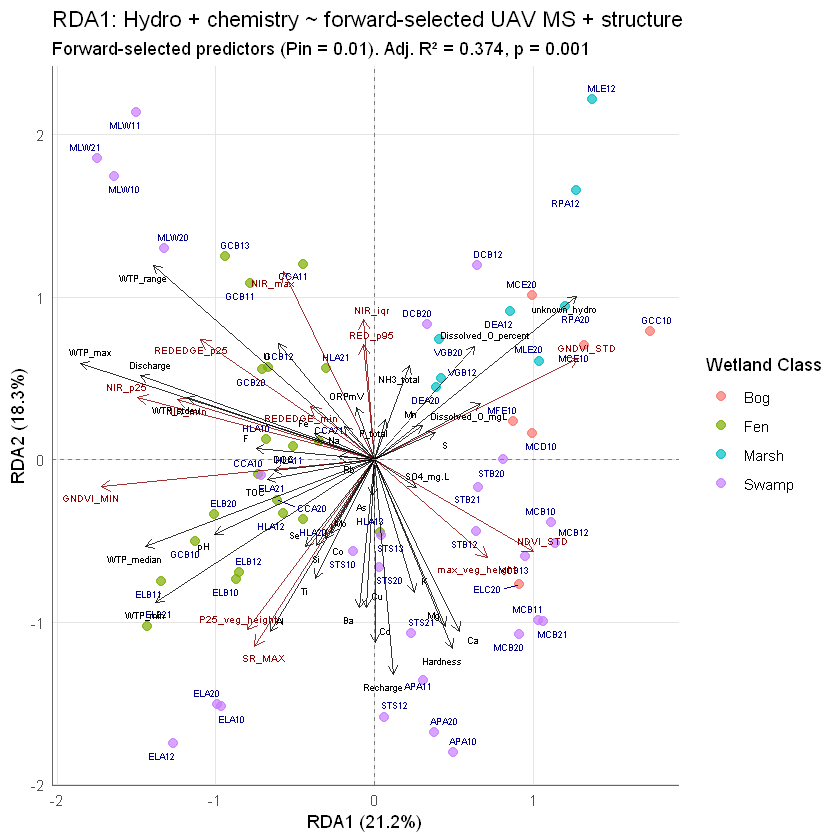

In [22]:
# ==============================
# STEP 4: Extract scores
# ==============================

# Site scores
site_scores <- as.data.frame(scores(rda_final, display = "sites", scaling = 2))
site_scores$SiteID <- rownames(site_scores)
site_scores$Class  <- df$Class  # wetland class for coloring

# Predictor arrows (vegetation variables = constrained predictors)
arrow_scores <- as.data.frame(scores(rda_final, display = "bp", scaling = 2))
arrow_scores$Variable <- rownames(arrow_scores)

# Response arrows (hydro + chem = 'species' in vegan's language)
response_scores <- as.data.frame(scores(rda_final, display = "species", scaling = 2))
response_scores$Variable <- rownames(response_scores)

# ==============================
# Axis labels with variance explained
# ==============================

eig <- summary(rda_final)$concont$importance[2, 1:2]  # proportion of constrained variance for RDA1 & RDA2
xlab_pct <- paste0("RDA1 (", round(eig[1] * 100, 1), "%)")
ylab_pct <- paste0("RDA2 (", round(eig[2] * 100, 1), "%)")

# ==============================
# Scale arrows for visibility
# ==============================

# Vegetation predictors (red arrows)
arrow_scale_veg <- 3
arrow_scores$RDA1_scaled <- arrow_scores$RDA1 * arrow_scale_veg
arrow_scores$RDA2_scaled <- arrow_scores$RDA2 * arrow_scale_veg

# Hydro + chem responses (black arrows)
arrow_scale_response <- 2
response_scores$RDA1_scaled <- response_scores$RDA1 * arrow_scale_response
response_scores$RDA2_scaled <- response_scores$RDA2 * arrow_scale_response

# ==============================
# Subtitle: adjusted R² + model p-value
# ==============================

subtitle_text <- sprintf(
  "Forward-selected predictors (Pin = 0.01). Adj. R² = %.3f, p = %.3f",
  r2_final$adj.r.squared,
  anova_final$`Pr(>F)`[1]
)

# ==============================
# Triplot (same style as before)
# ==============================

ggplot() +
  # Sites as points, coloured by wetland class
  geom_point(
    data = site_scores,
    aes(x = RDA1, y = RDA2, color = Class),
    size = 2.5, alpha = 0.7
  ) +
  
  # Site labels
  geom_text_repel(
    data = site_scores,
    aes(x = RDA1, y = RDA2, label = SiteID),
    color = "darkblue",
    size = 2,
    max.overlaps = 10
  ) +
  
  # Vegetation predictor arrows (RED)
  geom_segment(
    data = arrow_scores,
    aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
    arrow = arrow(length = unit(0.25, "cm")),
    color = "darkred",
    linewidth = 0.2,
    alpha = 0.8
  ) +
  
  # Vegetation predictor labels
  geom_text_repel(
    data = arrow_scores,
    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
    color = "darkred",
    size = 2.2,
    max.overlaps = 50,
    segment.color = NA,
    box.padding = 0.2
  ) +
  
  # Hydrogeochemistry response arrows (BLACK)
  geom_segment(
    data = response_scores,
    aes(x = 0, y = 0, xend = RDA1_scaled, yend = RDA2_scaled),
    arrow = arrow(length = unit(0.2, "cm")),
    color = "black",
    linewidth = 0.2,
    alpha = 0.8
  ) +
  
  # Hydrogeochemistry response labels
  geom_text_repel(
    data = response_scores,
    aes(x = RDA1_scaled, y = RDA2_scaled, label = Variable),
    color = "black",
    size = 2,
    max.overlaps = 200,
    segment.color = NA
  ) +
  
  # Reference lines
  geom_hline(yintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "gray50", linewidth = 0.3) +
  
  labs(
    title    = "RDA1: Hydro + chemistry ~ forward-selected UAV MS + structure",
    subtitle = subtitle_text,
    x = xlab_pct,
    y = ylab_pct,
    color = "Wetland Class"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    panel.grid.major = element_line(color = "grey90", linewidth = 0.2),
    panel.grid.minor = element_blank(),
    axis.line        = element_line(color = "grey40", linewidth = 0.3),
    legend.position  = "right"
  )


In [ ]:
# Predictor (constraining) scores
pred_scores <- as.data.frame(scores(rda_final, display = "bp", scaling = 2))
pred_scores$Variable <- rownames(pred_scores)

# Top N to show
N <- 10

# Top predictors for RDA1 (by absolute loading)
top_pred_RDA1 <- pred_scores[order(-abs(pred_scores$RDA1)), c("Variable", "RDA1")][1:N, ]
top_pred_RDA1

# Top predictors for RDA2
top_pred_RDA2 <- pred_scores[order(-abs(pred_scores$RDA2)), c("Variable", "RDA2")][1:N, ]
top_pred_RDA2


In [ ]:
# Response scores (hydro + chemistry)
resp_scores <- as.data.frame(scores(rda_final, display = "species", scaling = 2))
resp_scores$Variable <- rownames(resp_scores)

N <- 8  # top 8

# Top responses for RDA1
top_resp_RDA1 <- resp_scores[order(-abs(resp_scores$RDA1)), c("Variable", "RDA1")][1:N, ]
top_resp_RDA1

# Top responses for RDA2
top_resp_RDA2 <- resp_scores[order(-abs(resp_scores$RDA2)), c("Variable", "RDA2")][1:N, ]
top_resp_RDA2


## Kaiser–Guttman criterion 

In [ ]:
# Show me all the residual axes that have eigenvalues bigger than the average residual eigenvalue
# leftover gradients in the data that are not explained by the predictors
rda_final$CA$eig[rda_final$CA$eig > mean(rda_final$CA$eig)]
rda_global$CA$eig[rda_global$CA$eig > mean(rda_global$CA$eig)]


# PCA for Field Veg and Hydrochem

In [ ]:
hydro_cols <- hydro_cols[!grepl("VHG", hydro_cols)]
# Combine vegetation + hydrology + chemistry into one PCA matrix
pca_vars <- df[, c(field_cols, hydro_cols, chem_cols)]

# Scale everything before PCA
pca_scaled <- scale(pca_vars)

# Run PCA (vegan style)

pca_all <- rda(pca_scaled) 
summary(pca_all)
screeplot(pca_all, bstick = TRUE)

  

In [ ]:
# Top 10 vars on PC1
top_PC1 <- var_scores %>%
  arrange(desc(abs(PC1))) %>%
  slice_head(n = 10) %>%
  select(Variable, PC1)

# Top 10 vars on PC2
top_PC2 <- var_scores %>%
  arrange(desc(abs(PC2))) %>%
  slice_head(n = 10) %>%
  select(Variable, PC2)

top_PC1
top_PC2



In [ ]:
# Prepare data for ggplot
site_df <- as.data.frame(site_scores)
site_df$Class <- df$Class
site_df$SiteID <- df$SiteID

var_df <- as.data.frame(var_scores)
var_df$Variable <- rownames(var_df)

# Scale up the arrows by multiplying their coordinates
arrow_scale <- 1.5  # Adjust this to make arrows larger/smaller
var_df_scaled <- var_df
var_df_scaled$PC1 <- var_df$PC1 * arrow_scale
var_df_scaled$PC2 <- var_df$PC2 * arrow_scale

# Create biplot with SiteID labels
ggplot() +
  # Site points colored by class
  geom_point(data = site_df, 
             aes(x = PC1, y = PC2, color = Class),
             size = 3, alpha = 0.7) +
  # SiteID labels near points
  geom_text(data = site_df,
            aes(x = PC1, y = PC2, label = SiteID),
            size = 2, hjust = 1.2, vjust = 0, 
            check_overlap = FALSE) +
  # Variable arrows (scaled larger)
  geom_segment(data = var_df_scaled,
               aes(x = 0, y = 0, xend = PC1, yend = PC2),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "grey50", alpha = 0.5) +
  # Variable labels
  geom_text(data = var_df_scaled,
            aes(x = PC1, y = PC2, label = Variable),
            size = 2.5, hjust = 0, vjust = 0, 
            check_overlap = TRUE) +
  theme_bw() +
  labs(title = "PCA Biplot: Field + Hydrology + Chemistry",
       x = paste0("PC1 (", round(summary(pca_all)$cont$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_all)$cont$importance[2,2]*100, 1), "%)")) +
  coord_fixed()

# Alternative with top variables only
var_contrib <- rowSums(var_scores[, 1:2]^2)
top_vars <- names(sort(var_contrib, decreasing = TRUE)[1:20])

var_df_top <- var_df[var_df$Variable %in% top_vars, ]
var_df_top$PC1 <- var_df_top$PC1 * arrow_scale
var_df_top$PC2 <- var_df_top$PC2 * arrow_scale

ggplot() +
  geom_point(data = site_df, 
             aes(x = PC1, y = PC2, color = Class),
             size = 3, alpha = 0.7) +
  # SiteID labels
  geom_text(data = site_df,
            aes(x = PC1, y = PC2, label = SiteID),
            size = 2, hjust = 1.2, vjust = 0) +
  # Scaled arrows
  geom_segment(data = var_df_top,
               aes(x = 0, y = 0, xend = PC1, yend = PC2),
               arrow = arrow(length = unit(0.2, "cm")),
               color = "grey30", alpha = 0.6) +
  geom_text(data = var_df_top,
            aes(x = PC1, y = PC2, label = Variable),
            size = 3, hjust = 0, vjust = 0) +
  theme_bw() +
  labs(title = "PCA Biplot: Top 20 Contributing Variables",
       x = paste0("PC1 (", round(summary(pca_all)$cont$importance[2,1]*100, 1), "%)"),
       y = paste0("PC2 (", round(summary(pca_all)$cont$importance[2,2]*100, 1), "%)")) +
  coord_fixed()